# YOLO P3_v2
## phase3 : 소수 클래스 데이터 보강

| Category_id    AI허브 코드    클래스명    단일 존재

4542    K-004543    에어탈정(아세클로페낙)    ✅ TL_27

6191    K-006192    삐콤씨에프정 618.6mg/병    ✅ TL_30

16687    K-016688    오마코연질캡슐    ✅ TL_45

31862    K-031863    아질렉트정(라사길린메실산염)    ✅ TL_69

## 데이터 수정으로 재시작

- **목적**: 소수클래스 데이터 추가 후 v8s/11m 2개 모델 비교 (YOLO내장 증강 미적용)
- 노트북 순서: 환경설정 → 경로/데이터 sanity check → 함수 정의 → 2-run 학습 → VAL(0.001/0.25) → 클래스별 AP CSV → 요약

- 기타 실험 : v8m, v11l 모델 비교


## 1) 환경설정 및 라이브러리 임포트


In [1]:
# 충돌 이슈로 강제 설치
%pip install -q numpy==2.0.2 scipy==1.16.3 ultralytics==8.4.24

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.9 MB/s eta 0:00:00a 0:00:01


In [2]:
from pathlib import Path
import os
import sys
import time
import json
import random
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image as PILImage, ImageDraw

import torch
from ultralytics import YOLO

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


## 2) 경로/데이터 sanity check


In [4]:
# ===== 경로 설정 (필요 시 이 셀만 수정) =====
PROJECT_ROOT = Path('/content/drive/MyDrive/pill_detection_project') if IN_COLAB else Path.cwd()
DATA_ROOT = Path('/content/drive/MyDrive/data/초급_프로젝트/dataset/new_aug_v3') if IN_COLAB else PROJECT_ROOT / 'data'

# 공통 경로
TRAIN_JSON = DATA_ROOT / 'train_letterbox.json'
VAL_JSON = DATA_ROOT / 'val_letterbox.json'
VAL_IMAGE_DIR = DATA_ROOT / 'letterbox_images' / 'val'
TRAIN_IMAGE_DIR = DATA_ROOT / 'letterbox_images' / 'train'
CP_DATA_YAML = DATA_ROOT / 'data.yaml'
TRAIN_LABEL_DIR = TRAIN_IMAGE_DIR
VAL_LABEL_DIR = VAL_IMAGE_DIR

RUNS_DIR = PROJECT_ROOT / 'models' / 'yolo' / 'runs'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'yolo'
RUNS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('CP_DATA_YAML:', CP_DATA_YAML)

required = {
    'CP_DATA_YAML': CP_DATA_YAML,
    'TRAIN_JSON': TRAIN_JSON,
    'VAL_JSON': VAL_JSON,
    'TRAIN_IMAGE_DIR': TRAIN_IMAGE_DIR,
    'VAL_IMAGE_DIR': VAL_IMAGE_DIR,
}
missing = [k for k, v in required.items() if not Path(v).exists()]
if missing:
    for k in missing:
        print('[누락]', k, '->', required[k])
    raise FileNotFoundError('필수 경로 누락')

with open(CP_DATA_YAML, 'r', encoding='utf-8') as f:
    print()
    print('[data_yaml 미리보기]')
    for i, line in enumerate(f.readlines()[:20], 1):
        print(f'{i:02d}:', line.rstrip())


def _count_files(path, exts):
    p = Path(path)
    exts = {e.lower() for e in exts}
    return len([x for x in p.rglob('*') if x.is_file() and x.suffix.lower() in exts])

print()
print('[파일 개수 점검]')
print('train img/lbl:', _count_files(TRAIN_IMAGE_DIR, {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}), '/', _count_files(TRAIN_LABEL_DIR, {'.txt'}))
print('val   img/lbl:', _count_files(VAL_IMAGE_DIR, {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}), '/', _count_files(VAL_LABEL_DIR, {'.txt'}))


PROJECT_ROOT: /content/drive/MyDrive/pill_detection_project
CP_DATA_YAML: /content/drive/MyDrive/data/초급_프로젝트/dataset/new_aug_v3/data.yaml

[data_yaml 미리보기]
01: # YOLO data.yaml
02: path: /content/drive/MyDrive/data/초급_프로젝트/dataset
03: train: letterbox_images/train
04: val:   letterbox_images/val
05: # 라벨 폴더가 labels가 아닐 경우 명시적으로 지정하거나,
06: # YOLOv8 규칙에 따라 'yolo_labels'를 인식하게 합니다.
07: names: ['보령부스파정 5mg', '울트라셋이알서방정', '동아가바펜틴정 800mg', '놀텍정 10mg', '비모보정 500/20mg', '세비카정 10/40mg', '기넥신에프정(은행엽엑스)(수출용)', '자누비아정 50mg', '플라빅스정 75mg', '라비에트정 20mg', '가바토파정 100mg', '레일라정', '글리틴정(콜린알포세레이트)', '리피토정 20mg', '일양하이트린정 2mg', '아토젯정 10/40mg', '카발린캡슐 25mg', '로수젯정10/5밀리그램', '트윈스타정 40/5mg', '트라젠타정(리나글립틴)', '크레스토정 20mg', '자누메트정 50/850mg', '써스펜8시간이알서방정 650mg', '큐시드정 31.5mg/PTP', '비타비백정 100mg/병', '뮤테란캡슐 100mg', '카나브정 60mg', '조인스정 200mg', '무코스타정(레바미피드)(비매품)', '자이프렉사정 2.5mg', '스토가정 10mg', '엑스포지정 5/160mg', '자누메트엑스알서방정 100/1000mg', '리바로정 4mg', '노바스크정 5mg', '에빅사정(메만틴염산염)(비매품)', '알드린정', '리렉스펜정 300mg/PTP', '리피로우정 20

In [5]:
#@title: 라벨 파일 유효성 점검 (1회만 실행)
def _scan_label_validity(label_dir, max_files=2000):
    label_files = sorted(Path(label_dir).rglob('*.txt'))[:max_files]
    bad = 0
    for lp in label_files:
        for line in lp.read_text(encoding='utf-8', errors='ignore').splitlines():
            if not line.strip():
                continue
            ps = line.split()
            if len(ps) != 5:
                bad += 1
                continue
            try:
                _, x, y, w, h = ps
                x, y, w, h = float(x), float(y), float(w), float(h)
                if not (0.0 <= x <= 1.0 and 0.0 <= y <= 1.0 and 0.0 <= w <= 1.0 and 0.0 <= h <= 1.0):
                    bad += 1
                if w <= 0 or h <= 0:
                    bad += 1
            except Exception:
                bad += 1
    return bad

print('라벨 이상 행 수 (train 샘플):', _scan_label_validity(TRAIN_LABEL_DIR, max_files=2000))
print('라벨 이상 행 수 (val 샘플):', _scan_label_validity(VAL_LABEL_DIR, max_files=2000))

라벨 이상 행 수 (train 샘플): 0
라벨 이상 행 수 (val 샘플): 0


In [3]:
#@title: GT 샘플 시각화 함수
def visualize_gt_samples(img_dir, lbl_dir, sample_n=5, seed=42, title='GT 샘플'):
    img_dir = Path(img_dir)
    lbl_dir = Path(lbl_dir)
    imgs = sorted([
        p for p in img_dir.rglob('*')
        if p.is_file() and p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    ])
    if not imgs:
        print('이미지가 없습니다:', img_dir)
        return

    random.seed(seed)
    picks = random.sample(imgs, k=min(sample_n, len(imgs)))

    plt.figure(figsize=(12, 3 * len(picks)))
    for i, ip in enumerate(picks, 1):
        im = PILImage.open(ip).convert('RGB')
        w0, h0 = im.size
        draw = ImageDraw.Draw(im)
        lp = lbl_dir / f'{ip.stem}.txt'

        if lp.exists():
            for line in lp.read_text(encoding='utf-8', errors='ignore').splitlines():
                ps = line.split()
                if len(ps) != 5:
                    continue
                c, x, y, w, h = ps
                x, y, w, h = float(x), float(y), float(w), float(h)

                x1 = (x - w / 2) * w0
                y1 = (y - h / 2) * h0
                x2 = (x + w / 2) * w0
                y2 = (y + h / 2) * h0

                draw.rectangle([x1, y1, x2, y2], outline=(0, 255, 0), width=2)
                draw.text((x1 + 2, max(0, y1 - 12)), str(c), fill=(0, 255, 0))

        plt.subplot(len(picks), 1, i)
        plt.imshow(im)
        plt.title(f'{title} | {ip.name}', fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


[시각 sanity] train 샘플


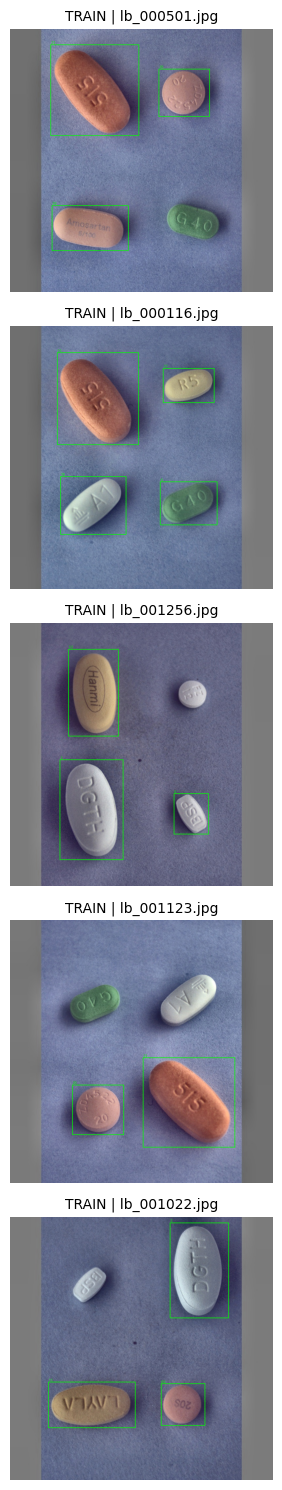

[시각 sanity] val 샘플


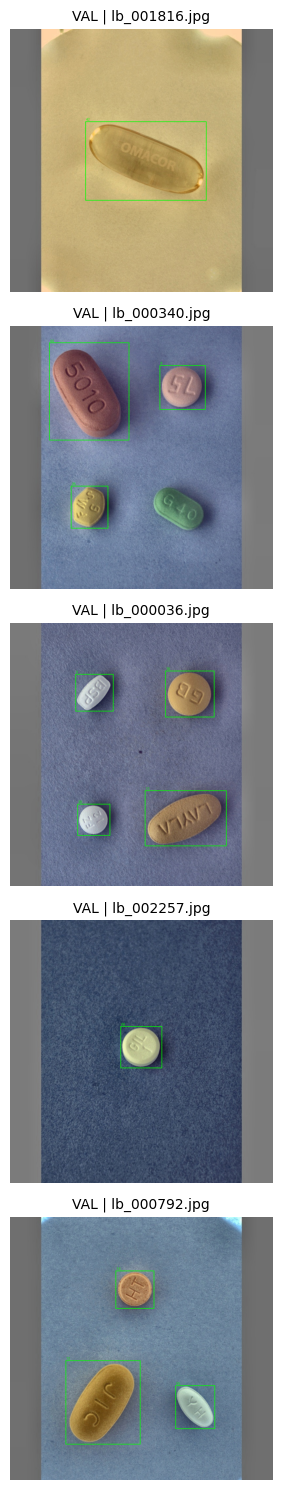

In [4]:
print()
print('[시각 sanity] train 샘플')
visualize_gt_samples(TRAIN_IMAGE_DIR, TRAIN_LABEL_DIR, sample_n=5, seed=42, title='TRAIN')
print('[시각 sanity] val 샘플')
visualize_gt_samples(VAL_IMAGE_DIR, VAL_LABEL_DIR, sample_n=5, seed=42, title='VAL')

## 3) 공통 함수 섹션


In [4]:
#@title 평가 함수 로드
eval_file = PROJECT_ROOT / 'src' / 'evaluation' / 'evaluation.py'
if not eval_file.exists():
    raise FileNotFoundError(f'evaluation.py not found: {eval_file}')

spec = importlib.util.spec_from_file_location('eval_mod', str(eval_file))
eval_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(eval_mod)
convert_yolo_results = eval_mod.convert_yolo_results
evaluate_all = eval_mod.evaluate_all

# 공통 하이퍼파라미터
EPOCHS = 30
IMGSZ = 800
BATCH = 16
OPTIMIZER = 'SGD'
PATIENCE = 10
PRED_IOU = 0.70


def _aug_kwargs(aug_mode: str):
    if aug_mode == 'noaug':
        return dict(
            augment=False,
            mosaic=0.0,
            mixup=0.0,
            copy_paste=0.0,
            fliplr=0.0,
            flipud=0.0,
            hsv_h=0.0,
            hsv_s=0.0,
            hsv_v=0.0,
            erasing=0.0,
        )

    if aug_mode == 'weakaug':
        return dict(
            augment=True,
            mosaic=0.1,
            close_mosaic=10,
            mixup=0.0,
            copy_paste=0.0,
            fliplr=0.0,
            flipud=0.0,
            hsv_h=0.005,
            hsv_s=0.1,
            hsv_v=0.1,
            erasing=0.0,
        )

    raise ValueError(f'Unknown aug_mode: {aug_mode}')


def train_one_run(exp: dict):
    run_name = exp['run_name']
    model_weight = exp['model_weight']
    aug_mode = exp['aug_mode']

    print('\n' + '=' * 80)
    print(f'학습 시작: {run_name} | 모델={model_weight} | 증강={aug_mode}')

    t0 = time.time()
    model = YOLO(model_weight)
    model.train(
        data=str(CP_DATA_YAML),
        epochs=EPOCHS,
        imgsz=IMGSZ,
        batch=BATCH,
        optimizer=OPTIMIZER,
        patience=PATIENCE,
        project=str(RUNS_DIR),
        name=run_name,
        exist_ok=True,
        pretrained=True,
        val=True,
        plots=False,
        verbose=True,
        **_aug_kwargs(aug_mode),
    )

    run_dir = RUNS_DIR / run_name
    best_pt = run_dir / 'weights' / 'best.pt'
    hist_csv = run_dir / 'results.csv'

    rec = {
        'run_name': run_name,
        'model_weight': model_weight,
        'aug_mode': aug_mode,
        'best_pt': str(best_pt),
        'history_csv': str(hist_csv),
        'runtime_min': (time.time() - t0) / 60.0,
    }

    if hist_csv.exists():
        h = pd.read_csv(hist_csv)
        rec['epochs_logged'] = int(len(h))
        if len(h):
            rec['train_box_loss'] = float(h['train/box_loss'].iloc[-1]) if 'train/box_loss' in h.columns else np.nan
            rec['train_cls_loss'] = float(h['train/cls_loss'].iloc[-1]) if 'train/cls_loss' in h.columns else np.nan
            rec['train_dfl_loss'] = float(h['train/dfl_loss'].iloc[-1]) if 'train/dfl_loss' in h.columns else np.nan
    else:
        rec['epochs_logged'] = np.nan
        rec['train_box_loss'] = np.nan
        rec['train_cls_loss'] = np.nan
        rec['train_dfl_loss'] = np.nan

    return rec


def _build_yolo_to_cat(train_json_path):
    with open(train_json_path, 'r', encoding='utf-8') as f:
        train_coco = json.load(f)
    cat_ids = sorted({int(a['category_id']) for a in train_coco['annotations']})
    return {i: cid for i, cid in enumerate(cat_ids)}


def _predict_and_eval(best_pt, gt_json_path, image_dir, conf_th):
    yolo2cat = _build_yolo_to_cat(TRAIN_JSON)

    with open(gt_json_path, 'r', encoding='utf-8') as f:
        gt_coco = json.load(f)
    filename_to_image_id = {Path(img['file_name']).name: int(img['id']) for img in gt_coco['images']}

    model = YOLO(str(best_pt))
    pred_results = model.predict(
        source=str(image_dir),
        imgsz=IMGSZ,
        conf=conf_th,
        iou=PRED_IOU,
        save=False,
        verbose=False,
    )

    valid_results, image_ids = [], []
    for r in pred_results:
        fname = Path(r.path).name
        if fname in filename_to_image_id:
            valid_results.append(r)
            image_ids.append(filename_to_image_id[fname])

    yolo_predictions = convert_yolo_results(valid_results, image_ids=image_ids)

    mapped = []
    for pred in yolo_predictions:
        cls_idx = int(pred['category_id'])
        if cls_idx not in yolo2cat:
            continue
        p = dict(pred)
        p['category_id'] = int(yolo2cat[cls_idx])
        mapped.append(p)

    if len(mapped) == 0:
        metrics = {'mAP@50': 0.0, 'mAP@75:95': 0.0, 'precision': 0.0, 'recall': 0.0}
    else:
        metrics = evaluate_all(
            gt_json_path=str(gt_json_path),
            predictions=mapped,
            conf_threshold=conf_th,
            pr_iou_threshold=0.5,
            temp_json_path=str(RESULTS_DIR / f'temp_eval_{Path(best_pt).stem}_{str(conf_th).replace(".", "p")}.json'),
        )

    return {
        'mAP50_95': float(metrics.get('mAP@75:95', np.nan)),
        'mAP50': float(metrics.get('mAP@50', np.nan)),
        'precision': float(metrics.get('precision', np.nan)),
        'recall': float(metrics.get('recall', np.nan)),
        'num_predictions': int(len(mapped)),
    }


def eval_val_dual_threshold(run_name, best_pt):
    rec_001 = _predict_and_eval(best_pt, VAL_JSON, VAL_IMAGE_DIR, conf_th=0.001)
    rec_025 = _predict_and_eval(best_pt, VAL_JSON, VAL_IMAGE_DIR, conf_th=0.25)

    return {
        'run_name': run_name,
        'mAP50_95@0.001': rec_001['mAP50_95'],
        'mAP50@0.001': rec_001['mAP50'],
        'precision@0.001': rec_001['precision'],
        'recall@0.001': rec_001['recall'],
        'num_pred@0.001': rec_001['num_predictions'],
        'mAP50_95@0.25': rec_025['mAP50_95'],
        'mAP50@0.25': rec_025['mAP50'],
        'precision@0.25': rec_025['precision'],
        'recall@0.25': rec_025['recall'],
        'num_pred@0.25': rec_025['num_predictions'],
    }


def save_class_ap_csv(run_name, best_pt):
    model = YOLO(str(best_pt))
    m = model.val(data=str(CP_DATA_YAML), split='val', imgsz=IMGSZ, batch=BATCH, plots=False, verbose=False)

    rows = []
    for i, (a50, a9595) in enumerate(zip(m.box.ap50, m.box.ap)):
        rows.append({
            'run_name': run_name,
            'class_idx': int(i),
            'class_name': str(model.names[i]),
            'AP50': float(a50),
            'AP50_95': float(a9595),
        })

    df_cls = pd.DataFrame(rows)
    out_csv = RESULTS_DIR / f'class_ap_{run_name}.csv'
    df_cls.to_csv(out_csv, index=False)

    return {
        'run_name': run_name,
        'class_ap_csv': str(out_csv),
        'class_AP50_mean': float(df_cls['AP50'].mean()),
        'class_AP50_95_mean': float(df_cls['AP50_95'].mean()),
    }


## 4) 2-run 학습 
 
- YOLO8s / YOLO11m 비교
- YOLO 내장 증강 미적용 고정


In [ ]:
# 실험 모델 2개
EXPERIMENTS = [
    {'run_name': 'yolov8s_cp_v3_base30_noaug', 'model_weight': 'yolov8s.pt', 'aug_mode': 'noaug'},
    {'run_name': 'yolo11m_cp_v3_base30_noaug', 'model_weight': 'yolo11m.pt', 'aug_mode': 'noaug'},
]

TRAIN_ARTIFACTS = []
for exp in EXPERIMENTS:
    TRAIN_ARTIFACTS.append(train_one_run(exp))

train_df = pd.DataFrame(TRAIN_ARTIFACTS)
train_df = train_df.sort_values('runtime_min').reset_index(drop=True)
display(train_df)

train_out = RESULTS_DIR / 'p3_v1_train_artifacts.csv'
train_df.to_csv(train_out, index=False)
print('저장 완료:', train_out)



학습 시작: yolov8s_cp_v3_base30_noaug | 모델=yolov8s.pt | 증강=noaug
New https://pypi.org/project/ultralytics/8.4.30 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.24 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/data/초급_프로젝트/dataset/new_aug_v3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0

> 런타임이 끊긴 건지 오류가 났는지 가중치 저장도 안돼고 로그가 멈춰버림

## 5) VAL 공통평가 (0.001 / 0.25 동시)


In [14]:
VAL_EVAL_ROWS = []
for rec in TRAIN_ARTIFACTS:
    best_pt = Path(rec['best_pt'])
    if not best_pt.exists():
        print('[건너뜀] best.pt 없음:', best_pt)
        continue

    print()
    print('[평가]', rec['run_name'])
    row = eval_val_dual_threshold(rec['run_name'], best_pt)
    VAL_EVAL_ROWS.append(row)

val_eval_df = pd.DataFrame(VAL_EVAL_ROWS).sort_values('mAP50_95@0.25', ascending=False).reset_index(drop=True)
display(val_eval_df)

val_out = RESULTS_DIR / 'p3_v1_val_dual_threshold.csv'
val_eval_df.to_csv(val_out, index=False)
print('저장 완료:', val_out)



[평가] yolov8s_cp_base30_noaug
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.24s).
Accumulating evaluation results...
DONE (t=0.34s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.871
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.875
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.875
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.869
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.951
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.951
 Average Recall     (AR) @[ IoU=0.

,run_name,mAP50_95@0.001,mAP50@0.001,precision@0.001,recall@0.001,num_pred@0.001,mAP50_95@0.25,mAP50@0.25,precision@0.25,recall@0.25,num_pred@0.25
0,yolov8s_cp_base30_noaug,0.865625,0.875406,0.533101,0.918,861,0.855998,0.864740,0.800000,0.888,555
1,yolo11m_cp_base30_noaug,0.863087,0.866880,0.305985,0.910,1487,0.853238,0.855624,0.788909,0.882,559
2,yolo11m_cp_base30_weakaug,0.862840,0.878582,0.266472,0.914,1715,0.848937,0.863420,0.776614,0.890,573
3,yolov8s_cp_base30_weakaug,0.864103,0.873846,0.593830,0.924,778,0.835688,0.843828,0.793226,0.890,561


저장 완료: /content/drive/MyDrive/pill_detection_project/results/yolo/p3_v1_val_dual_threshold.csv


## 5) 클래스별 AP

In [5]:
#@title 클래스별 AP 전체 저장 
DATA_YAML =  DATA_ROOT / 'data.yaml'
TRAIN_JSON = TRAIN_JSON = DATA_ROOT / 'train_letterbox.json'
TARGET_RUNS = [
    "yolov8s_cp_v3_base30_noaug",
    "yolo11m_cp_v3_base30_noaug",
]

# class_idx -> 원본 category_id 매핑
with open(TRAIN_JSON, "r", encoding="utf-8") as f:
    coco = json.load(f)
orig_category_ids = sorted({int(a["category_id"]) for a in coco["annotations"]})
cls2cat = {i: cid for i, cid in enumerate(orig_category_ids)}

all_rows = []

for run_name in TARGET_RUNS:
    best_pt = RUNS_DIR / run_name / "weights" / "best.pt"
    if not best_pt.exists():
        print("[SKIP] 가중치 없음:", best_pt)
        continue

    model = YOLO(str(best_pt))
    m = model.val(
        data=str(DATA_YAML),
        split="val",
        imgsz=IMGSZ,
        batch=BATCH,
        plots=False,
        verbose=False
    )

    names = model.names
    rows = []
    for i, (a50, a95) in enumerate(zip(m.box.ap50, m.box.ap)):
        class_name = names[i] if isinstance(names, list) else names.get(i, str(i))
        orig_cat = int(cls2cat[i])

        rows.append({
            "run_name": run_name,
            "class_idx": i,
            "class_name": class_name,
            "orig_category_id": orig_cat,
            "kaggle_category_id": orig_cat + 1,
            "AP50": float(a50),
            "AP50_95": float(a95),
        })

    run_df = pd.DataFrame(rows).sort_values("AP50_95", ascending=False).reset_index(drop=True)
    run_csv = RESULTS_DIR / f"class_ap_full_{run_name}.csv"
    run_df.to_csv(run_csv, index=False, encoding="utf-8-sig")
    print("[저장]", run_csv, "| rows:", len(run_df))

    all_rows.extend(rows)

# 전체 run 합본
all_df = pd.DataFrame(all_rows)
all_csv = RESULTS_DIR / "class_ap_full_p3_base30_noaug.csv"
all_df.to_csv(all_csv, index=False, encoding="utf-8-sig")
print("[저장]", all_csv, "| rows:", len(all_df))

display(all_df.head(10))


Ultralytics 8.4.24 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 11,153,835 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.1 ms, read: 0.5±0.1 MB/s, size: 151.1 KB)
val: Scanning /content/drive/MyDrive/data/초급_프로젝트/dataset/letterbox_images/val.cache... 139 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 139/139 18.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 34.3s/it 5:0836.9s59
                   all        139        431      0.752       0.97      0.897      0.894
Speed: 10.1ms preprocess, 1314.2ms inference, 0.0ms loss, 3.5ms postprocess per image
[저장] /content/drive/MyDrive/pill_detection_project/results/yolo/class_ap_full_yolov8s_cp_v3_base30_noaug.csv | rows: 73
Ultralytics 8.4.24 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11m summary (fused): 126 layers, 20,086,315 parameters, 0 gradients, 68

,run_name,class_idx,class_name,orig_category_id,kaggle_category_id,AP50,AP50_95
0,yolov8s_cp_v3_base30_noaug,0,보령부스파정 5mg,1899,1900,0.860854,0.855325
1,yolov8s_cp_v3_base30_noaug,1,울트라셋이알서방정,2482,2483,0.873810,0.873810
2,yolov8s_cp_v3_base30_noaug,2,동아가바펜틴정 800mg,3350,3351,0.902697,0.902697
3,yolov8s_cp_v3_base30_noaug,3,놀텍정 10mg,3482,3483,0.796000,0.796000
4,yolov8s_cp_v3_base30_noaug,4,비모보정 500/20mg,3543,3544,0.944231,0.944231
5,yolov8s_cp_v3_base30_noaug,5,세비카정 10/40mg,3742,3743,0.923889,0.923889
6,yolov8s_cp_v3_base30_noaug,6,기넥신에프정(은행엽엑스)(수출용),3831,3832,0.764000,0.764000
7,yolov8s_cp_v3_base30_noaug,7,자누비아정 50mg,4377,4378,0.995000,0.995000
8,yolov8s_cp_v3_base30_noaug,8,플라빅스정 75mg,4542,4543,0.830000,0.830000
9,yolov8s_cp_v3_base30_noaug,9,라비에트정 20mg,5093,5094,0.813611,0.813611


> 요약

    - 이전 실험에서 낮은 지표를 기록했던 몇몇 클래스의 지표가 눈에 띄게 상승했으나,
    - 반대로 안정적으로 높은 지표를 기록했던 몇몇 클래스의 지표가 낮아지는 현상이 발생했다.
    - 추가된 소수 클래스 4개 중 2개는 급상승, 2개는 변화 미미함

클래스명,P2 (보강 전),P3 (보강 후),지표 변화폭

비타비백정 100mg/병,0.995,0.331,🔻 -0.663

카발린캡슐 25mg,0.995,0.497,🔻 -0.497

일양하이트린정 2mg,0.918,0.527,🔻 -0.390

타이레놀이알서방정,0.995,0.636,🔻 -0.358

트라젠타정(리나글립틴),0.995,0.656,🔻 -0.338

리피로우정 20mg,0.995,0.663,🔻 -0.331

큐시드정 31.5mg/PTP,0.995,0.753,🔻 -0.241

In [13]:
# 1. 파일 로드 및 공백 제거 
p2_path = RESULTS_DIR / 'class_ap_all_runs_p2.csv'
p3_path = RESULTS_DIR / 'class_ap_full_all_runs_p3.csv'

df_p2 = pd.read_csv(p2_path)
df_p3 = pd.read_csv(p3_path)

df_p2.columns = df_p2.columns.str.strip()
df_p3.columns = df_p3.columns.str.strip()

# 2. 8s 모델 데이터 추출
df_p2_8s = df_p2[df_p2['run_name'] == 'yolov8s_no_cp_augon_final'][['class_name', 'AP50']].rename(columns={'AP50': '8s_P2'})
df_p3_8s = df_p3[df_p3['run_name'] == 'yolov8s_cp_v3_base30_noaug'][['class_name', 'AP50']].rename(columns={'AP50': '8s_P3'})

# 3. 11m 모델 데이터 추출
df_p2_11m = df_p2[df_p2['run_name'] == 'yolo11m_cp_augon_final'][['class_name', 'AP50']].rename(columns={'AP50': '11m_P2'})
df_p3_11m = df_p3[df_p3['run_name'] == 'yolo11m_cp_v3_base30_noaug'][['class_name', 'AP50']].rename(columns={'AP50': '11m_P3'})

# 4. 하나의 테이블로 전부 병합 (Merge)
df_comp = df_p2_8s.merge(df_p3_8s, on='class_name', how='inner')
df_comp = df_comp.merge(df_p2_11m, on='class_name', how='inner')
df_comp = df_comp.merge(df_p3_11m, on='class_name', how='inner')

# 5. 각 모델별 점수 변화폭 계산
df_comp['8s_변화폭'] = df_comp['8s_P3'] - df_comp['8s_P2']
df_comp['11m_변화폭'] = df_comp['11m_P3'] - df_comp['11m_P2']

# 컬럼 순서 깔끔하게 정리
df_comp = df_comp[['class_name', '8s_P2', '8s_P3', '8s_변화폭', '11m_P2', '11m_P3', '11m_변화폭']]

# -------------------------------------------------------------
# [결과 1] 두 모델 중 하나라도 5%p(0.05) 이상 크게 "상승한" 약들
# -------------------------------------------------------------
increased = df_comp[(df_comp['8s_변화폭'] > 0.05) | (df_comp['11m_변화폭'] > 0.05)].sort_values(by='11m_변화폭', ascending=False)
print("=== P3에서 점수가 크게 [높아진] 클래스 ===")
display(increased.head(15).style.background_gradient(cmap='Greens', subset=['8s_변화폭', '11m_변화폭']))

print("\n" + "="*80 + "\n")

# -------------------------------------------------------------
# [결과 2] 두 모델 중 하나라도 5%p(0.05) 이상 크게 "하락한" 약들
# -------------------------------------------------------------
decreased = df_comp[(df_comp['8s_변화폭'] < -0.05) | (df_comp['11m_변화폭'] < -0.05)].sort_values(by='11m_변화폭', ascending=True)
print("=== P3에서 점수가 크게 [낮아진] 클래스 (Trade-off) ===")
display(decreased.head(15).style.background_gradient(cmap='Reds_r', subset=['8s_변화폭', '11m_변화폭']))

=== P3에서 점수가 크게 [높아진] 클래스 ===


,class_name,8s_P2,8s_P3,8s_변화폭,11m_P2,11m_P3,11m_변화폭
14,리렉스펜정 300mg/PTP,0.749150,0.995000,0.245850,0.448593,0.995000,0.546407
8,에어탈정(아세클로페낙),0.696429,0.995000,0.298571,0.456250,0.995000,0.538750
66,글리틴정(콜린알포세레이트),0.497500,0.995000,0.497500,0.497500,0.995000,0.497500
24,오마코연질캡슐(오메가-3-산에틸에스테르90),0.995000,0.995000,0.000000,0.497500,0.995000,0.497500
16,자이프렉사정 2.5mg,0.995000,0.995000,0.000000,0.497500,0.972143,0.474643
40,맥시부펜이알정 300mg,0.584750,0.967222,0.382472,0.636957,0.926111,0.289155
1,뮤테란캡슐 100mg,0.771136,0.995000,0.223864,0.757930,0.995000,0.237070
18,써스펜8시간이알서방정 650mg,0.663333,0.976250,0.312917,0.787500,0.995000,0.207500
23,동아가바펜틴정 800mg,0.730536,0.902697,0.172162,0.704664,0.893078,0.188414
68,아토젯정 10/40mg,0.882423,0.945000,0.062577,0.710714,0.895000,0.184286




=== P3에서 점수가 크게 [낮아진] 클래스 (Trade-off) ===


,class_name,8s_P2,8s_P3,8s_변화폭,11m_P2,11m_P3,11m_변화폭
43,비타비백정 100mg/병,0.663333,0.331667,-0.331667,0.995000,0.331667,-0.663333
60,아질렉트정(라사길린메실산염),0.331667,0.497500,0.165833,0.995000,0.497500,-0.497500
71,카발린캡슐 25mg,0.995000,0.995000,0.000000,0.995000,0.497500,-0.497500
2,일양하이트린정 2mg,0.905989,0.721100,-0.184889,0.918297,0.527483,-0.390813
10,타이레놀이알서방정(아세트아미노펜)(수출용),0.828333,0.575707,-0.252627,0.995000,0.636750,-0.358250
53,트라젠타정(리나글립틴),0.995000,0.945000,-0.050000,0.995000,0.656250,-0.338750
38,리피로우정 20mg,0.995000,0.828333,-0.166667,0.995000,0.663333,-0.331667
46,큐시드정 31.5mg/PTP,0.995000,0.768235,-0.226765,0.995000,0.753235,-0.241765
61,자누메트엑스알서방정 100/1000mg,0.861667,0.663333,-0.198333,0.895000,0.663333,-0.231667
51,울트라셋이알서방정,0.995000,0.873810,-0.121190,0.995000,0.807136,-0.187864


## 6) 요약


In [16]:
summary_df = train_df.merge(val_eval_df, on='run_name', how='left').merge(
    class_summary_df[['run_name', 'class_AP50_mean', 'class_AP50_95_mean']],
    on='run_name',
    how='left'
)
summary_df = summary_df.sort_values(
    ['mAP50_95@0.25', 'mAP50_95@0.001', 'runtime_min'],
    ascending=[False, False, True]
).reset_index(drop=True)

display(summary_df)

summary_out = RESULTS_DIR / 'p3_v1_stage1_summary.csv'
summary_df.to_csv(summary_out, index=False)
print('저장 완료:', summary_out)


,run_name,model_weight,aug_mode,best_pt,history_csv,runtime_min,epochs_logged,train_box_loss,train_cls_loss,train_dfl_loss,...,precision@0.001,recall@0.001,num_pred@0.001,mAP50_95@0.25,mAP50@0.25,precision@0.25,recall@0.25,num_pred@0.25,class_AP50_mean,class_AP50_95_mean
0,yolov8s_cp_base30_noaug,yolov8s.pt,noaug,/content/drive/MyDrive/pill_detection_project/...,/content/drive/MyDrive/pill_detection_project/...,19.851638,30,0.14787,0.30651,0.78426,...,0.533101,0.918,861,0.855998,0.864740,0.800000,0.888,555,0.896565,0.894142
1,yolo11m_cp_base30_noaug,yolo11m.pt,noaug,/content/drive/MyDrive/pill_detection_project/...,/content/drive/MyDrive/pill_detection_project/...,35.944770,30,0.14901,0.30088,0.78430,...,0.305985,0.910,1487,0.853238,0.855624,0.788909,0.882,559,0.884732,0.883644
2,yolo11m_cp_base30_weakaug,yolo11m.pt,weakaug,/content/drive/MyDrive/pill_detection_project/...,/content/drive/MyDrive/pill_detection_project/...,34.550892,29,0.15526,0.31707,0.78507,...,0.266472,0.914,1715,0.848937,0.863420,0.776614,0.890,573,0.910964,0.905494
3,yolov8s_cp_base30_weakaug,yolov8s.pt,weakaug,/content/drive/MyDrive/pill_detection_project/...,/content/drive/MyDrive/pill_detection_project/...,16.271885,30,0.15023,0.31000,0.78693,...,0.593830,0.924,778,0.835688,0.843828,0.793226,0.890,561,0.891302,0.886772


저장 완료: /content/drive/MyDrive/pill_detection_project/results/yolo/p3_v1_stage1_summary.csv


# 7) 추가 실험 : 다른 모델 도입

## 7-1. 8m, 11l 학습 및 평가

In [17]:
# no_cp 먼저 (v8m + 11l)
DATA_YAML = "/content/drive/MyDrive/data/초급_프로젝트/dataset/data_aug_v1.yaml"

EXPERIMENTS = [
    {"run_name": "yolov8m_no_cp_v3_base30_noaug", "model_weight": "yolov8m.pt", "aug_mode": "noaug"},
    {"run_name": "yolo11l_no_cp_v3_base30_noaug", "model_weight": "yolo11l.pt", "aug_mode": "noaug"},
]

TRAIN_ARTIFACTS = []
for exp in EXPERIMENTS:
    TRAIN_ARTIFACTS.append(train_one_run(exp))

train_df = pd.DataFrame(TRAIN_ARTIFACTS).sort_values("runtime_min").reset_index(drop=True)
display(train_df)

train_out = RESULTS_DIR / "p3_v2_train_artifacts_no_cp.csv"
train_df.to_csv(train_out, index=False)
print("저장 완료:", train_out)



학습 시작: yolov8m_no_cp_v3_base30_noaug | 모델=yolov8m.pt | 증강=noaug
New https://pypi.org/project/ultralytics/8.4.30 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.24 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/data/초급_프로젝트/dataset/new_aug_v2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=

,run_name,model_weight,aug_mode,best_pt,history_csv,runtime_min,epochs_logged,train_box_loss,train_cls_loss,train_dfl_loss
0,yolov8m_no_cp_v3_base30_noaug,yolov8m.pt,noaug,/content/drive/MyDrive/pill_detection_project/...,/content/drive/MyDrive/pill_detection_project/...,30.511580,30,0.14076,0.29907,0.78328
1,yolo11l_no_cp_v3_base30_noaug,yolo11l.pt,noaug,/content/drive/MyDrive/pill_detection_project/...,/content/drive/MyDrive/pill_detection_project/...,44.739958,30,0.15014,0.31023,0.79136


저장 완료: /content/drive/MyDrive/pill_detection_project/results/yolo/p3_v2_train_artifacts_no_cp.csv


- VAL 공통평가 (0.001 / 0.25 동시)


In [18]:
VAL_EVAL_ROWS = []
for rec in TRAIN_ARTIFACTS:
    best_pt = Path(rec['best_pt'])
    if not best_pt.exists():
        print('[건너뜀] best.pt 없음:', best_pt)
        continue

    print()
    print('[평가]', rec['run_name'])
    row = eval_val_dual_threshold(rec['run_name'], best_pt)
    VAL_EVAL_ROWS.append(row)

val_eval_df = pd.DataFrame(VAL_EVAL_ROWS).sort_values('mAP50_95@0.25', ascending=False).reset_index(drop=True)
display(val_eval_df)

val_out = RESULTS_DIR / 'p3_v1_val_dual_threshold.csv'
val_eval_df.to_csv(val_out, index=False)
print('저장 완료:', val_out)



[평가] yolov8m_no_cp_v3_base30_noaug
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.25s).
Accumulating evaluation results...
DONE (t=0.34s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.891
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.896
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.896
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.889
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.958
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.958
 Average Recall     (AR) @[ 

,run_name,mAP50_95@0.001,mAP50@0.001,precision@0.001,recall@0.001,num_pred@0.001,mAP50_95@0.25,mAP50@0.25,precision@0.25,recall@0.25,num_pred@0.25
0,yolov8m_no_cp_v3_base30_noaug,0.886037,0.895942,0.426863,0.928,1087,0.853639,0.860986,0.796763,0.886,556
1,yolo11l_no_cp_v3_base30_noaug,0.858252,0.869454,0.446184,0.912,1022,0.849823,0.859565,0.765009,0.892,583


저장 완료: /content/drive/MyDrive/pill_detection_project/results/yolo/p3_v1_val_dual_threshold.csv


- 클래스별 AP


In [19]:
#@title 클래스별 AP 전체 저장 
# no_cp 기준 경로
DATA_YAML = Path("/content/drive/MyDrive/data/초급_프로젝트/dataset/data_aug_v1.yaml")
TRAIN_JSON = Path("/content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_train_final.json")

TARGET_RUNS = [
    "yolov8m_no_cp_v3_base30_noaug",
    "yolo11l_no_cp_v3_base30_noaug",
]

# class_idx -> 원본 category_id 매핑
with open(TRAIN_JSON, "r", encoding="utf-8") as f:
    coco = json.load(f)
orig_category_ids = sorted({int(a["category_id"]) for a in coco["annotations"]})
cls2cat = {i: cid for i, cid in enumerate(orig_category_ids)}

all_rows = []

for run_name in TARGET_RUNS:
    best_pt = RUNS_DIR / run_name / "weights" / "best.pt"
    if not best_pt.exists():
        print("[SKIP] 가중치 없음:", best_pt)
        continue

    model = YOLO(str(best_pt))
    m = model.val(
        data=str(DATA_YAML),
        split="val",
        imgsz=IMGSZ,
        batch=BATCH,
        plots=False,
        verbose=False
    )

    names = model.names
    rows = []
    for i, (a50, a95) in enumerate(zip(m.box.ap50, m.box.ap)):
        class_name = names[i] if isinstance(names, list) else names.get(i, str(i))
        orig_cat = int(cls2cat[i])

        rows.append({
            "run_name": run_name,
            "class_idx": i,
            "class_name": class_name,
            "orig_category_id": orig_cat,
            "kaggle_category_id": orig_cat + 1,
            "AP50": float(a50),
            "AP50_95": float(a95),
        })

    run_df = pd.DataFrame(rows).sort_values("AP50_95", ascending=False).reset_index(drop=True)
    run_csv = RESULTS_DIR / f"class_ap_full_{run_name}.csv"
    run_df.to_csv(run_csv, index=False, encoding="utf-8-sig")
    print("[저장]", run_csv, "| rows:", len(run_df))

    all_rows.extend(rows)

# 전체 run 합본
all_df = pd.DataFrame(all_rows)
all_csv = RESULTS_DIR / "class_ap_full_all_runs.csv"
all_df.to_csv(all_csv, index=False, encoding="utf-8-sig")
print("[저장]", all_csv, "| rows:", len(all_df))

display(all_df.head(10))


Ultralytics 8.4.24 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Model summary (fused): 93 layers, 25,882,027 parameters, 0 gradients, 78.9 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 0.3±0.0 MB/s, size: 146.8 KB)
val: Scanning /content/drive/MyDrive/data/초급_프로젝트/dataset/letterbox_images_aug_v1/val.cache... 139 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 139/139 41.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 3.3s/it 29.7s0.3s0
                   all        139        431      0.802      0.942      0.897      0.893
Speed: 1.1ms preprocess, 14.8ms inference, 0.0ms loss, 0.8ms postprocess per image
[저장] /content/drive/MyDrive/pill_detection_project/results/yolo/class_ap_full_yolov8m_no_cp_v3_base30_noaug.csv | rows: 73
Ultralytics 8.4.24 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11l summary (fused): 191 layers, 25,335,595 parameters, 0 gradient

,run_name,class_idx,class_name,orig_category_id,kaggle_category_id,AP50,AP50_95
0,yolov8m_no_cp_v3_base30_noaug,0,보령부스파정 5mg,1899,1900,0.871190,0.871190
1,yolov8m_no_cp_v3_base30_noaug,1,울트라셋이알서방정,2482,2483,0.770762,0.744852
2,yolov8m_no_cp_v3_base30_noaug,2,동아가바펜틴정 800mg,3350,3351,0.915963,0.915963
3,yolov8m_no_cp_v3_base30_noaug,3,놀텍정 10mg,3482,3483,0.812769,0.812769
4,yolov8m_no_cp_v3_base30_noaug,4,비모보정 500/20mg,3543,3544,0.937308,0.937308
5,yolov8m_no_cp_v3_base30_noaug,5,세비카정 10/40mg,3742,3743,0.943889,0.943889
6,yolov8m_no_cp_v3_base30_noaug,6,기넥신에프정(은행엽엑스)(수출용),3831,3832,0.830000,0.816305
7,yolov8m_no_cp_v3_base30_noaug,7,자누비아정 50mg,4377,4378,0.995000,0.995000
8,yolov8m_no_cp_v3_base30_noaug,8,플라빅스정 75mg,4542,4543,0.806429,0.806429
9,yolov8m_no_cp_v3_base30_noaug,9,라비에트정 20mg,5093,5094,0.841746,0.841746


## 7-2. 요약


In [20]:
summary_df = train_df.merge(val_eval_df, on='run_name', how='left').merge(
    class_summary_df[['run_name', 'class_AP50_mean', 'class_AP50_95_mean']],
    on='run_name',
    how='left'
)
summary_df = summary_df.sort_values(
    ['mAP50_95@0.25', 'mAP50_95@0.001', 'runtime_min'],
    ascending=[False, False, True]
).reset_index(drop=True)

display(summary_df)

summary_out = RESULTS_DIR / 'p3_v1_stage1_summary.csv'
summary_df.to_csv(summary_out, index=False)
print('저장 완료:', summary_out)


,run_name,model_weight,aug_mode,best_pt,history_csv,runtime_min,epochs_logged,train_box_loss,train_cls_loss,train_dfl_loss,...,precision@0.001,recall@0.001,num_pred@0.001,mAP50_95@0.25,mAP50@0.25,precision@0.25,recall@0.25,num_pred@0.25,class_AP50_mean,class_AP50_95_mean
0,yolov8m_no_cp_v3_base30_noaug,yolov8m.pt,noaug,/content/drive/MyDrive/pill_detection_project/...,/content/drive/MyDrive/pill_detection_project/...,30.511580,30,0.14076,0.29907,0.78328,...,0.426863,0.928,1087,0.853639,0.860986,0.796763,0.886,556,NaN,NaN
1,yolo11l_no_cp_v3_base30_noaug,yolo11l.pt,noaug,/content/drive/MyDrive/pill_detection_project/...,/content/drive/MyDrive/pill_detection_project/...,44.739958,30,0.15014,0.31023,0.79136,...,0.446184,0.912,1022,0.849823,0.859565,0.765009,0.892,583,NaN,NaN


저장 완료: /content/drive/MyDrive/pill_detection_project/results/yolo/p3_v1_stage1_summary.csv
